# SSL pretrain: masked patch MAE (log-STFT + ViT + LF-PE)

Self-supervised pretrain encoder на log-STFT 128×256: случайная маска ~45% патчей 16×16, encoder + decoder, MSE только на замaskированных патчах.

**Данные:** только train split (85%), без меток. Val split — для мониторинга reconstruction loss.

**Чекпоинт encoder:** `checkpoints/vit_lfpe_ssl_pretrain_best.pt`

**Resume:** `RESUME_FROM_BEST`, `CLEARML_CONTINUE_LAST`, `CLEARML_TASK_ID` — в ячейке ClearML.


In [1]:
from pathlib import Path
import os
import sys
import warnings
import math

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import soundfile as sf
from scipy import signal
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from IPython.display import display
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


# ClearML и пути

Пути к данным и чекпоинтам, `.env`, device, ClearML.


In [2]:
PROJECT_DIR = Path("/Users/katterns/ITMO/Practice")
sys.path.insert(0, str(PROJECT_DIR))

DATA_DIR = PROJECT_DIR / "cleaned_subset_200"
METADATA_PATH = DATA_DIR / "audio_metadata_cleaned.csv"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
BEST_CKPT = CHECKPOINT_DIR / "vit_lfpe_ssl_pretrain_best.pt"
TRAIN_LOG_TXT = CHECKPOINT_DIR / "vit_lfpe_ssl_pretrain_log.txt"

import logging
from dotenv import load_dotenv

load_dotenv(PROJECT_DIR / ".env", override=False)

CLEARML_QUIET = os.environ.get("CLEARML_QUIET", "1").strip().lower() in ("1", "true", "yes")
CLEARML_UPLOAD_EACH_BEST = os.environ.get("CLEARML_UPLOAD_EACH_BEST", "0").strip().lower() in (
    "1", "true", "yes",
)


def setup_clearml_console(quiet: bool = True) -> None:
    if not quiet:
        return
    for name in ("clearml", "clearml.storage", "clearml.model", "clearml.Task"):
        logging.getLogger(name).setLevel(logging.WARNING)
    try:
        from clearml.storage.callbacks import ProgressReport

        def _no_tqdm(self):
            self._tqdm_init = True
            return None

        ProgressReport._get_tqdm = _no_tqdm
    except Exception:
        pass


setup_clearml_console(CLEARML_QUIET)

from clearml import OutputModel, Task

device = torch.device("mps")

RESUME_FROM_BEST = True
CLEARML_CONTINUE_LAST = True
CLEARML_TASK_ID = None
CLEARML_PROJECT = "my project"
CLEARML_TASK_NAME = "vit_lfpe_ssl_pretrain_2sec"

clearml_output_uri = os.environ.get("CLEARML_OUTPUT_URI", True)
if isinstance(clearml_output_uri, str) and clearml_output_uri.lower() in ("false", "0", "no", "none"):
    clearml_output_uri = False

_task_init_kw = dict(
    project_name=CLEARML_PROJECT,
    task_name=CLEARML_TASK_NAME,
    output_uri=clearml_output_uri,
    auto_resource_monitoring=False,
)
if CLEARML_TASK_ID:
    _task_init_kw["continue_last_task"] = CLEARML_TASK_ID
    _task_init_kw["reuse_last_task_id"] = CLEARML_TASK_ID
elif CLEARML_CONTINUE_LAST and RESUME_FROM_BEST:
    _task_init_kw["continue_last_task"] = 0
    _task_init_kw["reuse_last_task_id"] = True
else:
    _task_init_kw["reuse_last_task_id"] = False

clearml_task = Task.init(**_task_init_kw)
output_dest = clearml_task.get_output_destination() or ""
output_model = OutputModel(
    task=clearml_task,
    name="vit_lfpe_ssl_pretrain",
    framework="pytorch",
)
if output_dest:
    output_model.set_upload_destination(output_dest)

if not CLEARML_QUIET:
    print("ClearML:", clearml_task.get_output_log_web_page())
print(
    "device:", device,
    "| quiet:", CLEARML_QUIET,
    "| upload each best:", CLEARML_UPLOAD_EACH_BEST,
    "| clearml continue:", (CLEARML_CONTINUE_LAST and RESUME_FROM_BEST) or bool(CLEARML_TASK_ID),
    "| clearml task:", clearml_task.id,
)


ClearML Task: overwriting (reusing) task id=0feb7024bdcf498e8448ecef7c1b8822
ClearML results page: https://app.clear.ml/projects/6c3eac4aaa974ff39b83424d3f26990c/experiments/0feb7024bdcf498e8448ecef7c1b8822/output/log
device: mps | quiet: True | upload each best: False | clearml continue: True | clearml task: 0feb7024bdcf498e8448ecef7c1b8822


# Аудио, STFT и аугментации

**192 kHz**, клип **2 s**. Train: crop, waveform gain jitter, log-STFT, SpecAugment. Val: center crop, без аугментаций.


In [3]:
TARGET_SR = 192_000
CLIP_SEC = 2.0
MIN_FREQ = 5_000
MAX_FREQ = 96_000
SPEC_H, SPEC_W = 128, 256
N_FFT = 2048
HOP_LENGTH = 512

SPEC_TIME_MASK_MAX = 24
SPEC_FREQ_MASK_MAX = 16
GAIN_JITTER_DB = 6.0

ENERGY_CROP_PROB = 0.7
ENERGY_CROP_CANDIDATES = 8
WAV_GAIN_JITTER_DB = 6.0

AUGMENT_START_EPOCH = 30
AUGMENT_RAMP_EVERY = 5
AUGMENT_RAMP_STEPS = 10


def resample_audio(y: np.ndarray, orig_sr: float, target_sr: float) -> np.ndarray:
    if int(orig_sr) == int(target_sr):
        return y.astype(np.float32)
    t_old = np.linspace(0.0, len(y) / orig_sr, num=len(y), endpoint=False)
    t_new = np.linspace(
        0.0,
        len(y) / orig_sr,
        num=int(len(y) * target_sr / orig_sr),
        endpoint=False,
    )
    return np.interp(t_new, t_old, y).astype(np.float32)


def center_crop_or_pad(y: np.ndarray, target_len: int) -> np.ndarray:
    if len(y) >= target_len:
        i0 = (len(y) - target_len) // 2
        return y[i0 : i0 + target_len]
    out = np.zeros(target_len, dtype=np.float32)
    i0 = (target_len - len(y)) // 2
    out[i0 : i0 + len(y)] = y
    return out


def random_crop_or_pad(y: np.ndarray, target_len: int, rng: np.random.Generator) -> np.ndarray:
    if len(y) >= target_len:
        i0 = int(rng.integers(0, len(y) - target_len + 1))
        return y[i0 : i0 + target_len]
    out = np.zeros(target_len, dtype=np.float32)
    i0 = (target_len - len(y)) // 2
    out[i0 : i0 + len(y)] = y
    return out


def energy_biased_crop(
    y: np.ndarray, target_len: int, rng: np.random.Generator, n_candidates: int
) -> np.ndarray:
    if len(y) < target_len:
        return center_crop_or_pad(y, target_len)
    best_i0, best_e = 0, -1.0
    for _ in range(n_candidates):
        i0 = int(rng.integers(0, len(y) - target_len + 1))
        seg = y[i0 : i0 + target_len]
        e = float(np.mean(seg * seg))
        if e > best_e:
            best_e, best_i0 = e, i0
    return y[best_i0 : best_i0 + target_len]


def pick_train_crop(y: np.ndarray, target_len: int, rng: np.random.Generator) -> np.ndarray:
    if rng.random() < ENERGY_CROP_PROB:
        return energy_biased_crop(y, target_len, rng, ENERGY_CROP_CANDIDATES)
    return random_crop_or_pad(y, target_len, rng)


def maybe_gain_jitter(
    y: np.ndarray, rng: np.random.Generator, max_db: float | None = None
) -> np.ndarray:
    max_db = WAV_GAIN_JITTER_DB if max_db is None else max_db
    if max_db <= 0:
        return y
    gain = 10.0 ** (float(rng.uniform(-max_db, max_db)) / 20.0)
    return (y * gain).astype(np.float32)


def make_log_stft(audio: np.ndarray, sr: float) -> np.ndarray:
    audio = np.asarray(audio, dtype=np.float32)
    audio = audio[np.isfinite(audio)]
    if len(audio) < 8:
        raise ValueError("Audio too short")
    nperseg = int(min(N_FFT, len(audio)))
    hop = int(min(HOP_LENGTH, max(1, nperseg // 2)))
    noverlap = max(0, nperseg - hop)
    if noverlap >= nperseg:
        noverlap = nperseg - 1
    freqs, _, zxx = signal.stft(
        audio,
        fs=sr,
        nperseg=nperseg,
        noverlap=noverlap,
        boundary="zeros",
        padded=True,
    )
    spec = np.log1p(np.abs(zxx))
    keep = (freqs >= MIN_FREQ) & (freqs <= min(MAX_FREQ, sr / 2))
    return spec[keep]


def spec_to_tensor(spec: np.ndarray) -> torch.Tensor:
    spec = np.ascontiguousarray(spec, dtype=np.float32)
    x = torch.from_numpy(spec)[None, None]
    x = F.interpolate(x, size=(SPEC_H, SPEC_W), mode="bilinear", align_corners=False)
    x = x[0]
    x = (x - x.mean()) / (x.std().clamp_min(1e-6))
    return x


def augment_spec(x: torch.Tensor, rng: np.random.Generator, strength: float = 1.0) -> torch.Tensor:
    if strength <= 0:
        return x
    _, h, w = x.shape
    freq_max = int(round(SPEC_FREQ_MASK_MAX * strength))
    time_max = int(round(SPEC_TIME_MASK_MAX * strength))
    gain_db = GAIN_JITTER_DB * strength
    if freq_max > 0:
        fh = int(rng.integers(0, freq_max + 1))
        if fh > 0:
            f0 = int(rng.integers(0, max(1, h - fh)))
            x = x.clone()
            x[:, f0 : f0 + fh, :] = 0.0
    if time_max > 0:
        tw = int(rng.integers(0, time_max + 1))
        if tw > 0:
            t0 = int(rng.integers(0, max(1, w - tw)))
            x = x.clone()
            x[:, :, t0 : t0 + tw] = 0.0
    if gain_db > 0:
        gain = 10.0 ** (float(rng.uniform(-gain_db, gain_db)) / 20.0)
        x = x * gain
    return x


# Датасет (метаданные)

CSV, stratified split 85/15. **Pretrain только на train** — val не участвует в SSL, чтобы не было leakage перед fine-tune.


In [4]:
df = pd.read_csv(METADATA_PATH)
assert not df.empty, f"Пустой CSV: {METADATA_PATH}"

species_sorted = sorted(df["species"].unique())
label2id = {s: i for i, s in enumerate(species_sorted)}

df["label"] = df["species"].map(label2id)
df["path"] = df.apply(
    lambda r: DATA_DIR / str(r["species"]) / str(r["filename"]), axis=1
)
df = df[df["path"].apply(lambda p: p.is_file())].reset_index(drop=True)

train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=df["label"],
)
print(f"SSL train: {len(train_df)}  SSL val monitor: {len(val_df)}")


SSL train: 4348  SSL val monitor: 768


# Dataset

`BatWavSpectrogramSSLDataset` возвращает только спектрограмму `[1, 128, 256]` (метки не используются).


In [5]:
class BatWavSpectrogramSSLDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, training: bool = False):
        self.frame = frame.reset_index(drop=True)
        self.training = training
        self.rng = np.random.default_rng(RANDOM_SEED)
        self.aug_strength = 0.0

    def set_aug_strength(self, strength: float) -> None:
        self.aug_strength = float(max(0.0, min(1.0, strength)))

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        y, sr = sf.read(str(row["path"]), always_2d=False)
        if y.ndim > 1:
            y = y.mean(axis=-1)
        y = resample_audio(y, float(sr), float(TARGET_SR))
        tgt = int(CLIP_SEC * TARGET_SR)
        if self.training:
            y = pick_train_crop(y, tgt, self.rng)
            if self.aug_strength > 0:
                y = maybe_gain_jitter(
                    y, self.rng, max_db=WAV_GAIN_JITTER_DB * self.aug_strength
                )
        else:
            y = center_crop_or_pad(y, tgt)
        spec = make_log_stft(y, float(TARGET_SR))
        x = spec_to_tensor(spec)
        if self.training and self.aug_strength > 0:
            x = augment_spec(x, self.rng, strength=self.aug_strength)
        return x


# DataLoader

Train: shuffle. Val: reconstruction loss. Batch size 8 (encoder 256 dim, ~8M params).


In [6]:
train_ds = BatWavSpectrogramSSLDataset(train_df, training=True)
val_ds = BatWavSpectrogramSSLDataset(val_df, training=False)

BATCH_SIZE = 8
NUM_WORKERS = 0

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

xb = next(iter(train_loader))
print("batch:", xb.shape)


batch: torch.Size([8, 1, 128, 256])


# MAE модель

Encoder: 256 dim, 8 блоков, LF-PE + conv pos. Mask 75%, norm_pix_loss.

Общие блоки — в `vit_bat.py`, класс MAE ниже (как в остальных ноутбуках).


In [7]:
import importlib
import vit_bat
importlib.reload(vit_bat)
from vit_bat import (
    ConvPosEnc1d,
    LearnableFourierPosEncoding,
    PatchEmbed2D,
    TransformerBlock,
    make_normalized_grid,
    patch_energy,
    patchify,
    signal_aware_random_masking,
)

PATCH_SIZE = (16, 16)
EMBED_DIM = 256
ENC_DEPTH = 8
DEC_DEPTH = 4
DEC_DIM = 256
N_HEADS = 4
MLP_RATIO = 4.0
DROPOUT = 0.1
MASK_RATIO = 0.5
NOISE_PATCH_PERCENTILE = 25.0
NORM_PIX_LOSS = True
PE_TYPE = "lf"
CONV_POS_KERNEL = 33


class BatViTPatchMAE(nn.Module):
    def __init__(
        self,
        embed_dim=256,
        enc_depth=8,
        dec_depth=4,
        dec_dim=256,
        n_heads=4,
        patch_size=(16, 16),
        mlp_ratio=4.0,
        dropout=0.1,
        pe_type="lf",
        norm_pix_loss=True,
        conv_pos_kernel=33,
    ):
        super().__init__()
        self.norm_pix_loss = norm_pix_loss
        self.patch_size = patch_size
        self.patch_embed = PatchEmbed2D(1, embed_dim, patch_size)
        grid_f = SPEC_H // patch_size[0]
        grid_t = SPEC_W // patch_size[1]
        self.grid_shape = (grid_f, grid_t)
        self.num_patches = grid_f * grid_t
        self.patch_dim = patch_size[0] * patch_size[1]

        if pe_type != "lf":
            raise ValueError("SSL pretrain: only pe_type='lf'")
        self.pos_encoder = LearnableFourierPosEncoding(pe_dim=embed_dim)
        self.conv_pos = ConvPosEnc1d(embed_dim, kernel_size=conv_pos_kernel)
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, n_heads, mlp_ratio, dropout)
            for _ in range(enc_depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        self.decoder_embed = nn.Linear(embed_dim, dec_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, dec_dim))
        nn.init.trunc_normal_(self.mask_token, std=0.02)
        self.decoder_pos = LearnableFourierPosEncoding(pe_dim=dec_dim)
        self.decoder_blocks = nn.ModuleList([
            TransformerBlock(dec_dim, n_heads, mlp_ratio, dropout)
            for _ in range(dec_depth)
        ])
        self.decoder_norm = nn.LayerNorm(dec_dim)
        self.pred = nn.Linear(dec_dim, self.patch_dim)

    def _patch_pos(self, batch_size, device, pe_module):
        positions = make_normalized_grid(self.grid_shape, device=device)
        pe = pe_module(positions)
        return pe.unsqueeze(0).expand(batch_size, -1, -1)

    def _decode(self, latent, ids_restore, pad_mask, batch_size, device):
        dec = self.decoder_embed(latent)
        n = self.num_patches
        dec_full = torch.zeros(batch_size, n, dec.shape[-1], device=device, dtype=dec.dtype)
        keep_counts = (~pad_mask).sum(dim=1)
        for i in range(batch_size):
            nk = int(keep_counts[i].item())
            nd = n - nk
            row = torch.cat([dec[i, :nk], self.mask_token.squeeze(0).expand(nd, -1)], dim=0)
            dec_full[i] = row[ids_restore[i]]
        dec_full = dec_full + self._patch_pos(batch_size, device, self.decoder_pos)
        for blk in self.decoder_blocks:
            dec_full = blk(dec_full)
        return self.decoder_norm(dec_full)

    def forward(
        self,
        x,
        mask_ratio=MASK_RATIO,
        noise_percentile=NOISE_PATCH_PERCENTILE,
    ):
        targets = patchify(x, self.patch_size)
        if self.norm_pix_loss:
            mean = targets.mean(dim=-1, keepdim=True)
            var = targets.var(dim=-1, unbiased=True, keepdim=True)
            targets_loss = (targets - mean) / (var + 1e-6).sqrt()
        else:
            mean = var = None
            targets_loss = targets

        energies = patch_energy(x, self.patch_size)
        tokens, _ = self.patch_embed(x)
        b = tokens.shape[0]
        tokens = tokens + self._patch_pos(b, tokens.device, self.pos_encoder)
        tokens = self.conv_pos(tokens)
        tokens, mask, ids_restore, pad_mask = signal_aware_random_masking(
            tokens,
            mask_ratio,
            energies,
            noise_percentile=noise_percentile,
        )

        for blk in self.blocks:
            tokens = blk(tokens, key_padding_mask=pad_mask)
        latent = self.norm(tokens)
        pred = self.pred(
            self._decode(latent, ids_restore, pad_mask, b, tokens.device)
        )

        loss_per_patch = ((pred - targets_loss) ** 2).mean(dim=-1)
        loss = (loss_per_patch * mask).sum() / mask.sum().clamp_min(1.0)
        if self.norm_pix_loss:
            pred = pred * (var + 1e-6).sqrt() + mean
        return loss, pred, mask, targets

    def encoder_state_dict(self):
        keys = ("patch_embed", "pos_encoder", "conv_pos", "blocks", "norm")
        return {k: v for k, v in self.state_dict().items() if k.split(".")[0] in keys}


model = BatViTPatchMAE(
    embed_dim=EMBED_DIM,
    enc_depth=ENC_DEPTH,
    dec_depth=DEC_DEPTH,
    dec_dim=DEC_DIM,
    n_heads=N_HEADS,
    patch_size=PATCH_SIZE,
    mlp_ratio=MLP_RATIO,
    dropout=DROPOUT,
    pe_type=PE_TYPE,
    norm_pix_loss=NORM_PIX_LOSS,
    conv_pos_kernel=CONV_POS_KERNEL,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
enc_params = sum(p.numel() for p in model.encoder_state_dict().values())
print(f"MAE params: {n_params:,}  encoder: {enc_params:,}")
with torch.no_grad():
    loss, _, mask, _ = model(xb.to(device))
    print(
        "demo loss:", float(loss),
        "| masked signal patches:", float(mask.mean()),
    )


MAE params: 9,894,016  encoder: 6,561,216
demo loss: 1.3038913011550903 | masked signal patches: 0.375


# Гиперпараметры

AdamW (wd=0.05, betas 0.9/0.95 как в MAE), **cosine decay + 5-epoch warmup**, early stopping по val reconstruction loss.


In [8]:
BASE_LR = 1e-4
WEIGHT_DECAY = 0.05
MAX_EPOCHS = 100
PATIENCE = 15
WARMUP_EPOCHS = 5
MIN_LR = 1e-6
MAX_GRAD_NORM = 1.0

RESUME_LOWER_LR = False
FINETUNE_LR = 2.1e-5

def aug_strength_for_epoch(epoch: int) -> float:
    """0 до AUGMENT_START_EPOCH, затем +25% силы каждые AUGMENT_RAMP_EVERY эпох."""
    if epoch < AUGMENT_START_EPOCH:
        return 0.0
    step = (epoch - AUGMENT_START_EPOCH) // AUGMENT_RAMP_EVERY
    return min(1.0, (step + 1) / AUGMENT_RAMP_STEPS)



def set_epoch_lr(optimizer, epoch: int) -> float:
    if epoch <= WARMUP_EPOCHS:
        lr = BASE_LR * epoch / max(WARMUP_EPOCHS, 1)
    else:
        progress = (epoch - WARMUP_EPOCHS) / max(MAX_EPOCHS - WARMUP_EPOCHS, 1)
        lr = MIN_LR + 0.5 * (BASE_LR - MIN_LR) * (1.0 + math.cos(math.pi * progress))
    for pg in optimizer.param_groups:
        pg["lr"] = lr
    return lr


clearml_task.connect({
    "model": "vit_lfpe_mae_v3_signal_aware",
    "clip_sec": CLIP_SEC,
    "batch_size": BATCH_SIZE,
    "base_lr": BASE_LR,
    "mask_ratio": MASK_RATIO,
    "noise_patch_percentile": NOISE_PATCH_PERCENTILE,
    "augment_start_epoch": AUGMENT_START_EPOCH,
    "augment_ramp_every": AUGMENT_RAMP_EVERY,
    "embed_dim": EMBED_DIM,
    "enc_depth": ENC_DEPTH,
    "dec_depth": DEC_DEPTH,
    "dec_dim": DEC_DIM,
    "conv_pos": True,
    "norm_pix_loss": NORM_PIX_LOSS,
    "warmup_epochs": WARMUP_EPOCHS,
    "device": str(device),
    "resume_from_best": RESUME_FROM_BEST,
})

optimizer = optim.AdamW(
    model.parameters(),
    lr=BASE_LR,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.95),
)


# Обучение

`evaluate` — val reconstruction loss. `train_model` — цикл по эпохам, сохранение лучшего encoder по min val loss.


In [9]:
@torch.no_grad()
def evaluate(model):
    model.eval()
    loss_sum = 0.0
    n_batches = 0
    for batch_x in val_loader:
        batch_x = batch_x.to(device)
        loss, _, _, _ = model(
            batch_x,
            mask_ratio=MASK_RATIO,
            noise_percentile=NOISE_PATCH_PERCENTILE,
        )
        loss_sum += loss.item()
        n_batches += 1
    return loss_sum / max(n_batches, 1)


def _upload_checkpoint_to_clearml(epoch: int) -> str | None:
    if not output_dest:
        return None
    return output_model.update_weights(
        weights_filename=str(BEST_CKPT),
        upload_uri=output_dest or None,
        auto_delete_file=False,
        iteration=epoch,
    )


def _save_best_checkpoint(epoch, val_loss):
    torch.save(
        {
            "model_state": model.state_dict(),
            "encoder_state": model.encoder_state_dict(),
            "model_name": "vit_lfpe_mae",
            "config": {
                "target_sr": TARGET_SR,
                "clip_sec": CLIP_SEC,
                "min_freq": MIN_FREQ,
                "max_freq": MAX_FREQ,
                "spec_hw": (SPEC_H, SPEC_W),
                "patch_size": PATCH_SIZE,
                "embed_dim": EMBED_DIM,
                "enc_depth": ENC_DEPTH,
                "dec_depth": DEC_DEPTH,
                "dec_dim": DEC_DIM,
                "n_heads": N_HEADS,
                "pe_type": PE_TYPE,
                "conv_pos_kernel": CONV_POS_KERNEL,
                "mask_ratio": MASK_RATIO,
                "noise_patch_percentile": NOISE_PATCH_PERCENTILE,
                "norm_pix_loss": NORM_PIX_LOSS,
                "augment_start_epoch": AUGMENT_START_EPOCH,
                "augment_ramp_every": AUGMENT_RAMP_EVERY,
            },
            "val_recon_loss": val_loss,
            "epoch": epoch,
        },
        BEST_CKPT,
    )
    model_uri = None
    if CLEARML_UPLOAD_EACH_BEST:
        model_uri = _upload_checkpoint_to_clearml(epoch)
    line = f"epoch={epoch} val_recon_loss={val_loss:.6f}\n"
    TRAIN_LOG_TXT.write_text(
        (TRAIN_LOG_TXT.read_text(encoding="utf-8") if TRAIN_LOG_TXT.exists() else "")
        + line,
        encoding="utf-8",
    )
    if CLEARML_QUIET:
        tqdm.write(f"saved {BEST_CKPT.name}  val_loss={val_loss:.6f}")
    else:
        msg = f"saved {BEST_CKPT}"
        if model_uri:
            msg += f"  ClearML: {model_uri}"
        tqdm.write(msg)


def _load_resume_checkpoint(model, ckpt_path: Path):
    if not ckpt_path.is_file():
        raise FileNotFoundError(f"Resume: нет файла {ckpt_path}")
    try:
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    except TypeError:
        ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state"], strict=True)
    last_epoch = int(ckpt.get("epoch", 0))
    best_val_loss = float(ckpt.get("val_recon_loss", float("inf")))
    return last_epoch + 1, best_val_loss, last_epoch


def train_model(model, num_epochs=80, max_grad_norm=1.0, resume_from_best=False):
    history = {"train_loss": [], "val_loss": [], "aug_strength": []}
    best_val_loss = float("inf")
    best_epoch = 0
    epochs_no_improve = 0
    start_epoch = 1

    if resume_from_best:
        start_epoch, best_val_loss, best_epoch = _load_resume_checkpoint(model, BEST_CKPT)
        if RESUME_LOWER_LR:
            for pg in optimizer.param_groups:
                pg["lr"] = FINETUNE_LR
            tqdm.write(f"Resume LR: {FINETUNE_LR:.2e}")
        tqdm.write(
            f"Resume: {BEST_CKPT.name}  last_epoch={best_epoch}  "
            f"best_val_loss={best_val_loss:.6f}, epochs {start_epoch}..{num_epochs}"
        )
        if start_epoch > num_epochs:
            raise ValueError(f"Resume: start_epoch={start_epoch} > MAX_EPOCHS={num_epochs}")

    logger = clearml_task.get_logger()
    epoch_bar = tqdm(
        range(start_epoch, num_epochs + 1),
        desc="epochs",
        unit="epoch",
        initial=start_epoch - 1,
        total=num_epochs,
    )

    for epoch in epoch_bar:
        aug_s = aug_strength_for_epoch(epoch)
        train_ds.set_aug_strength(aug_s)
        lr_now = set_epoch_lr(optimizer, epoch)
        model.train()
        train_loss = 0.0
        n_batches = 0
        batch_bar = tqdm(train_loader, desc=f"train e{epoch}", leave=False, unit="batch", position=1)
        for batch_x in batch_bar:
            batch_x = batch_x.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss, _, _, _ = model(
                batch_x,
                mask_ratio=MASK_RATIO,
                noise_percentile=NOISE_PATCH_PERCENTILE,
            )
            loss.backward()
            if max_grad_norm is not None:
                nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()
            train_loss += loss.item()
            n_batches += 1
            batch_bar.set_postfix(loss=f"{loss.item():.4f}")

        tr_loss = train_loss / max(n_batches, 1)
        val_loss = evaluate(model)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["aug_strength"].append(aug_s)

        logger.report_scalar("loss", "train", tr_loss, iteration=epoch)
        logger.report_scalar("loss", "val", val_loss, iteration=epoch)
        logger.report_scalar("lr", "lr", lr_now, iteration=epoch)
        logger.report_scalar("aug", "strength", aug_s, iteration=epoch)

        epoch_bar.set_postfix(val_loss=f"{val_loss:.6f}", aug=f"{aug_s:.2f}")
        tqdm.write(
            f"Epoch {epoch:02d}  lr={lr_now:.2e}  aug={aug_s:.2f}  "
            f"train={tr_loss:.6f}  val={val_loss:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            epochs_no_improve = 0
            _save_best_checkpoint(epoch, val_loss)
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= PATIENCE:
            tqdm.write("Early stopping.")
            break

    epoch_bar.close()
    if best_val_loss < float("inf") and output_dest and not CLEARML_UPLOAD_EACH_BEST:
        uri = _upload_checkpoint_to_clearml(best_epoch)
        if not CLEARML_QUIET and uri:
            tqdm.write(f"ClearML upload (final best, ep {best_epoch}): {uri}")
    tqdm.write(f"best val recon loss: {best_val_loss:.6f}")
    return model, history


# Запуск pretrain


In [10]:
model, history = train_model(
    model,
    num_epochs=MAX_EPOCHS,
    max_grad_norm=MAX_GRAD_NORM,
    resume_from_best=RESUME_FROM_BEST,
)


Resume: vit_lfpe_ssl_pretrain_best.pt  last_epoch=88  best_val_loss=0.800056, epochs 89..100


epochs:  88%|########8 | 88/100 [00:00<?, ?epoch/s]

train e89:   0%|          | 0/544 [00:00<?, ?batch/s]

Epoch 89  lr=4.24e-06  aug=1.00  train=0.797789  val=0.799969
saved vit_lfpe_ssl_pretrain_best.pt  val_loss=0.799969


train e90:   0%|          | 0/544 [00:00<?, ?batch/s]

...

Epoch 98  lr=1.11e-06  aug=1.00  train=0.794215  val=0.795687
saved vit_lfpe_ssl_pretrain_best.pt  val_loss=0.795687


train e99:   0%|          | 0/544 [00:00<?, ?batch/s]

Epoch 99  lr=1.03e-06  aug=1.00  train=0.794689  val=0.794926
saved vit_lfpe_ssl_pretrain_best.pt  val_loss=0.794926


train e100:   0%|          | 0/544 [00:00<?, ?batch/s]

Epoch 100  lr=1.00e-06  aug=1.00  train=0.795772  val=0.794361
saved vit_lfpe_ssl_pretrain_best.pt  val_loss=0.794361
best val recon loss: 0.794361


# Визуализация reconstruction

**Train batch** — случайный crop и SpecAugment (как при обучении).

**Val** — center crop, без augment (как в демо прототипа): патчи 16×16, маска, reconstruction.


2026-06-05 12:21:26,863 - clearml.model - WARNING - Connecting multiple input models with the same name: `vit_lfpe_ssl_pretrain_best`. This might result in the wrong model being used when executing remotely
Train batch (crop + augment):


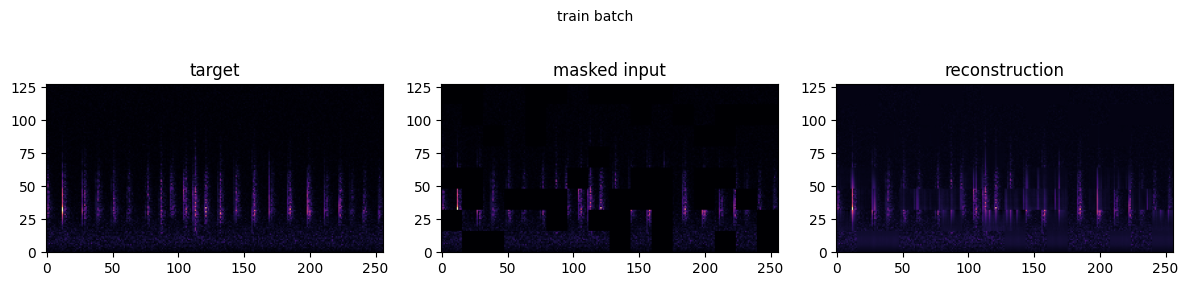

batch loss: 0.7944092154502869


In [11]:
@torch.no_grad()
def unpatchify_2d(patches_gf_gt_pf_pt):
    """(gf, gt, pf, pt) -> спектрограмма (H, W)."""
    pf, pt = PATCH_SIZE
    p = patches_gf_gt_pf_pt
    return p.permute(0, 2, 1, 3).reshape(p.shape[0] * pf, p.shape[1] * pt)


def show_reconstruction(model, batch_x, n_show=1, title=None):
    model.eval()
    x = batch_x[:n_show].to(device)
    loss, pred, mask, targets = model(x, mask_ratio=MASK_RATIO)
    pf, pt = PATCH_SIZE
    B, N, P = pred.shape
    gf, gt = model.grid_shape

    pred_patches = pred.view(B, gf, gt, pf, pt)
    tgt_patches = targets.view(B, gf, gt, pf, pt)
    mask_2d = mask.view(B, gf, gt)

    for i in range(n_show):
        m = mask_2d[i].bool()
        recon_p = tgt_patches[i].clone()
        recon_p[m] = pred_patches[i][m]

        masked_p = tgt_patches[i].clone()
        fill = tgt_patches[i].min()
        masked_p[m] = fill

        orig = x[i, 0].cpu().numpy()
        masked = unpatchify_2d(masked_p).cpu().numpy()
        recon_img = unpatchify_2d(recon_p).cpu().numpy()

        fig, axes = plt.subplots(1, 3, figsize=(12, 3))
        if title:
            fig.suptitle(title, fontsize=10)
        axes[0].imshow(orig, origin="lower", cmap="magma")
        axes[0].set_title("target")
        axes[1].imshow(masked, origin="lower", cmap="magma")
        axes[1].set_title("masked input")
        axes[2].imshow(recon_img, origin="lower", cmap="magma")
        axes[2].set_title("reconstruction")
        plt.tight_layout()
        plt.show()
    print("batch loss:", float(loss))


def wav_to_val_spec_tensor(row) -> torch.Tensor:
    y, sr = sf.read(str(row["path"]), always_2d=False)
    if y.ndim > 1:
        y = y.mean(axis=-1)
    y = resample_audio(y, float(sr), float(TARGET_SR))
    y = center_crop_or_pad(y, int(CLIP_SEC * TARGET_SR))
    spec = make_log_stft(y, float(TARGET_SR))
    return spec_to_tensor(spec).unsqueeze(0)


def show_val_patch_mask_demo(x, seed=RANDOM_SEED):
    spec_2d = x[0, 0].cpu().numpy()
    pf, pt = PATCH_SIZE
    spec_2d = spec_2d[: (spec_2d.shape[0] // pf) * pf, : (spec_2d.shape[1] // pt) * pt]
    nf, nt = spec_2d.shape[0] // pf, spec_2d.shape[1] // pt
    rng = np.random.default_rng(seed)
    n = nf * nt
    patch_vals = spec_2d.reshape(nf, pf, nt, pt).transpose(0, 2, 1, 3).reshape(n, pf * pt)
    energies = (patch_vals ** 2).mean(axis=1)
    thr = np.quantile(energies, NOISE_PATCH_PERCENTILE / 100.0)
    signal_idx = np.where(energies > thr)[0]
    if signal_idx.size < max(4, n // 4):
        signal_idx = np.argsort(energies)[-max(4, n // 4):]
    n_mask = max(1, int(round(signal_idx.size * MASK_RATIO)))
    pick = rng.choice(signal_idx, size=min(n_mask, signal_idx.size), replace=False)
    flat = np.zeros(n, dtype=bool)
    flat[pick] = True
    patch_mask = flat.reshape(nf, nt)

    spec_masked = spec_2d.copy()
    fill = spec_2d.min()
    for i in range(nf):
        for j in range(nt):
            if patch_mask[i, j]:
                spec_masked[i * pf : (i + 1) * pf, j * pt : (j + 1) * pt] = fill

    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    axes[0].imshow(spec_2d, origin="lower", cmap="magma")
    axes[0].set_title("input")
    axes[1].imshow(patch_mask, origin="lower", cmap="gray_r")
    axes[1].set_title("mask")
    axes[2].imshow(spec_masked, origin="lower", cmap="magma")
    axes[2].set_title("masked")
    plt.tight_layout()
    plt.show()


ckpt = torch.load(BEST_CKPT, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])

print("Train batch (crop + augment):")
show_reconstruction(model, xb, title="train batch")



# Val: center crop, без augment

Первый файл из val split — тот же режим, что в демо патчей.


val: ANPA/ANPA-73632748.wav


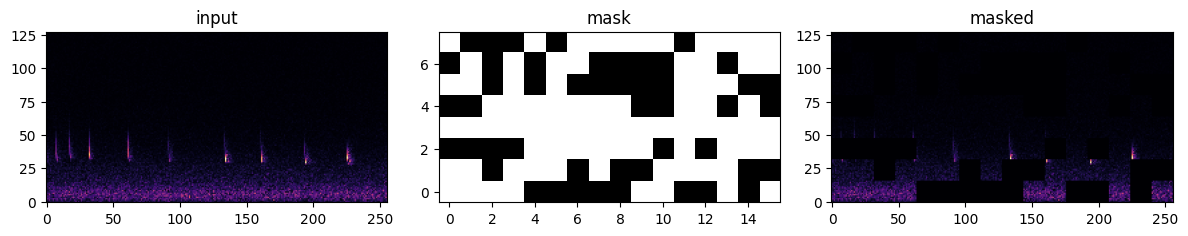

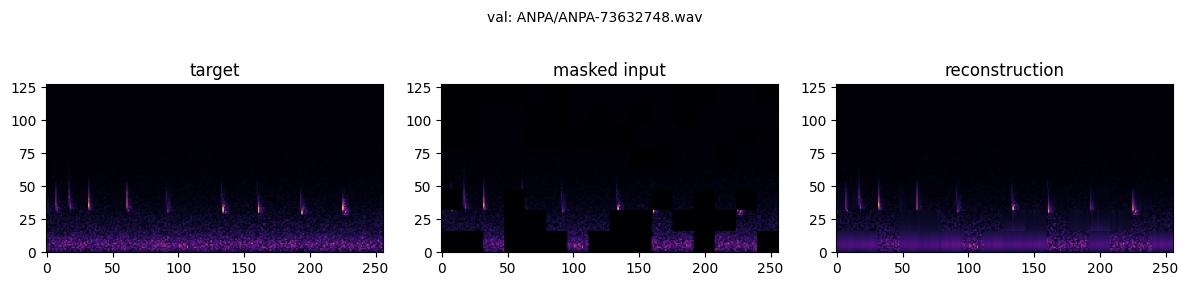

batch loss: 0.840617835521698


In [12]:
val_row = val_df.iloc[0]
val_x = wav_to_val_spec_tensor(val_row)
print(f"val: {val_row['species']}/{val_row['filename']}")

show_val_patch_mask_demo(val_x)
show_reconstruction(
    model,
    val_x,
    title=f"val: {val_row['species']}/{val_row['filename']}",
)
